# 01 - Data Extraction & Feature Engineering (Module-First)

Notebook nay chi dieu phoi ETL thong qua wrapper module `run_notebook01_etl`.

Luong chay:
1. Cau hinh date range, corridor/segment ids, output path
2. Goi `run_notebook01_etl(config)`
3. Kiem tra schema report + class distribution
4. Preview parquet dau ra

In [1]:
import os
import sys
from pathlib import Path

# Fix: Add project root to sys.path so 'src' can be imported
cwd = Path.cwd().resolve()
search_roots = [cwd] + list(cwd.parents)
PROJECT_ROOT = next(
    (p for p in search_roots if (p / 'src').exists()),
    cwd,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import ETL API with a safe fallback in case the kernel has a stale module
try:
    from src.pipelines.notebook01_etl import DEFAULT_CORRIDOR_IDS, Notebook01ETLConfig, run_notebook01_etl
except Exception as _err:
    import importlib
    import src.pipelines.notebook01_etl as _nb01
    _nb01 = importlib.reload(_nb01)
    DEFAULT_CORRIDOR_IDS = getattr(_nb01, "DEFAULT_CORRIDOR_IDS", [])
    Notebook01ETLConfig = getattr(_nb01, "Notebook01ETLConfig")
    run_notebook01_etl = getattr(_nb01, "run_notebook01_etl")
    print(f"Warning: reloaded src.pipelines.notebook01_etl due to import error: {_err}")

In [2]:
def _parse_ids(raw_value: str) -> list[int]:
    if not raw_value.strip():
        return []
    return [int(x.strip()) for x in raw_value.split(',') if x.strip()]

START_DATE = os.getenv('ETL_START_DATE', '2026-03-25')
END_DATE = os.getenv('ETL_END_DATE', '2026-04-26')
OUTPUT_PATH = os.getenv('ETL_OUTPUT_PATH', '/workspace/ai-core/data/processed/01_processed_features.parquet')
POOL_LIMIT = int(os.getenv('ETL_SEGMENT_POOL_LIMIT', '100'))

# Vi du: ETL_CORRIDOR_IDS="136550177913819656,392537437542429252"
# Hoac ETL_SEGMENT_IDS="123,456"
CORRIDOR_IDS = _parse_ids(os.getenv('ETL_CORRIDOR_IDS', '')) or DEFAULT_CORRIDOR_IDS
SEGMENT_IDS = _parse_ids(os.getenv('ETL_SEGMENT_IDS', ''))
PEAK_HOURS_ONLY = os.getenv('ETL_PEAK_HOURS_ONLY', 'true').lower() == 'true'

config = Notebook01ETLConfig(
    start_date=START_DATE,
    end_date=END_DATE,
    output_path=OUTPUT_PATH,
    corridor_ids=CORRIDOR_IDS or None,
    segment_ids=SEGMENT_IDS or None,
    peak_hours_only=PEAK_HOURS_ONLY,
)

print('Date range :', START_DATE, '->', END_DATE)
print('Output path:', OUTPUT_PATH)
print('Corridors  :', CORRIDOR_IDS)
print('Segments   :', SEGMENT_IDS if SEGMENT_IDS else '(none)')
print('Peak hours :', PEAK_HOURS_ONLY)
if not _parse_ids(os.getenv('ETL_CORRIDOR_IDS', '')) and not SEGMENT_IDS:
    print('Fallback  : default corridor list from module')

Date range : 2026-03-25 -> 2026-04-26
Output path: /workspace/ai-core/data/processed/01_processed_features.parquet
Corridors  : [14146616491042222, 73904187376705400, 132965186560956307, 136550177913819656, 392537437542429252, 418854844871232114, 499090817621594113, 553923893084418928, 646713380690000556, 647577676530405923, 665064665204826106, 757793456805938866, 934115805333902094, 988709510142577156, 1100735735503891924]
Segments   : (none)
Peak hours : True
Fallback  : default corridor list from module


In [3]:
RUN_ETL = True

if RUN_ETL:
    result = run_notebook01_etl(config)
    print('Saved       :', result.output_path)
    print('Shape       :', (result.rows, result.columns))
    print('Class counts:', result.class_counts)
    print('Missing cols:', result.schema_report.get('missing_columns'))
else:
    print('Dry-run: set RUN_ETL=True to execute ETL wrapper.')

🛣️ Tìm thấy 55 segments trong Corridor 14146616491042222.
📍 Đang tải dữ liệu cho 55 segments.
⚠️ Forecast mart stale cho segments 17824882530865980,35977559166783497,86483148102541410,88695839356853126,12413972 (max_ts=2026-04-25 18:12:33.056735), đang self-refresh nhẹ trước khi query...
✅ Self-refresh mart hoàn tất cho 55 segments.
✅ Đã tải 29123 dòng từ forecast mart cho 55 segments.
✅ Đã tải xong 29123 dòng dữ liệu thô từ DataMart/Warehouse. Đang tiến hành xử lý...
⚠️ Tổng hợp làm sạch congestion_level: đã loại bỏ 5104 dòng ở 29 segments.
📉 Top segments bị drop congestion_level cao nhất (theo tỷ lệ):
   - Segment 35977559166783497: drop 176/842 (20.90%)
   - Segment 124139722805884273: drop 176/842 (20.90%)
   - Segment 158739887205063974: drop 176/842 (20.90%)
   - Segment 189464599917416663: drop 176/842 (20.90%)
   - Segment 228751283832961915: drop 176/842 (20.90%)
   - Segment 327797655647855427: drop 176/842 (20.90%)
   - Segment 361718942936334244: drop 176/842 (20.90%)
   - 

In [4]:
output_path = Path(config.output_path)
assert output_path.exists(), f'Missing output parquet: {output_path}'

df = pd.read_parquet(output_path)
print('Reloaded shape:', df.shape)
print('Columns:', len(df.columns))
print('Class counts:\n', df['congestion_level'].value_counts().sort_index())
df.head(5)

Reloaded shape: (3127932, 19)
Columns: 19
Class counts:
 congestion_level
0.0    1054527
1.0    1358422
2.0     633046
3.0      77320
4.0       4251
5.0        366
Name: count, dtype: int64


,timestamp,segment_key,current_speed_kmh,traffic_index,delay_seconds,quality_flag,congestion_level,default_lane_count,free_flow_speed_kmh,tomtom_frc,weather_key,day_of_week,shift_code,is_peak_hour,is_business_hours,is_weekend,time_key,time_sin,time_cos
0,2026-03-25 06:00:00,149313672850875,41.0,0.21,265.0,9.0,1.0,2.0,52.0,0.0,802.0,3,EARLY_MORNING,1.0,0.0,0.0,360,1.000000,6.123234e-17
1,2026-03-25 06:30:00,149313672850875,37.0,0.30,418.0,9.0,2.0,2.0,53.0,0.0,802.0,3,EARLY_MORNING,1.0,0.0,0.0,390,0.991445,-1.305262e-01
2,2026-03-25 06:45:00,149313672850875,33.0,0.38,586.0,9.0,2.0,2.0,53.0,0.0,802.0,3,EARLY_MORNING,1.0,0.0,0.0,405,0.980785,-1.950903e-01
3,2026-03-25 07:15:00,149313672850875,34.0,0.36,541.0,9.0,2.0,2.0,53.0,0.0,802.0,3,MORNING_PEAK,1.0,0.0,0.0,435,0.946930,-3.214395e-01
4,2026-03-25 07:30:00,149313672850875,35.0,0.34,497.0,9.0,2.0,2.0,53.0,0.0,801.0,3,MORNING_PEAK,1.0,0.0,0.0,450,0.923880,-3.826834e-01


In [5]:
# Optional quick diagnostics
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print('Top missing columns (%):')
print(missing_pct.head(15))

Top missing columns (%):
timestamp              0.0
weather_key            0.0
time_sin               0.0
time_key               0.0
is_weekend             0.0
is_business_hours      0.0
is_peak_hour           0.0
shift_code             0.0
day_of_week            0.0
tomtom_frc             0.0
segment_key            0.0
free_flow_speed_kmh    0.0
default_lane_count     0.0
congestion_level       0.0
quality_flag           0.0
dtype: float64


In [6]:
# Quick analysis of dynamic features distribution
cols_to_plot = ['current_speed_kmh', 'traffic_index', 'delay_seconds']
if 'df' in globals():
    display(df[cols_to_plot].describe().T)
else:
    print('DataFrame "df" not found. Please run the ETL cells first.')


,count,mean,std,min,25%,50%,75%,max
current_speed_kmh,3127932.0,35.812926,10.263884,1.0,28.000,36.0,44.00,65.00
traffic_index,3127932.0,0.186984,0.135925,0.0,0.055,0.2,0.29,0.97
delay_seconds,3127932.0,292.360338,295.337418,0.0,9.000,218.0,449.00,1766.00


/tmp/ipykernel_1193/1182970226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='congestion_level', data=df, palette='viridis')


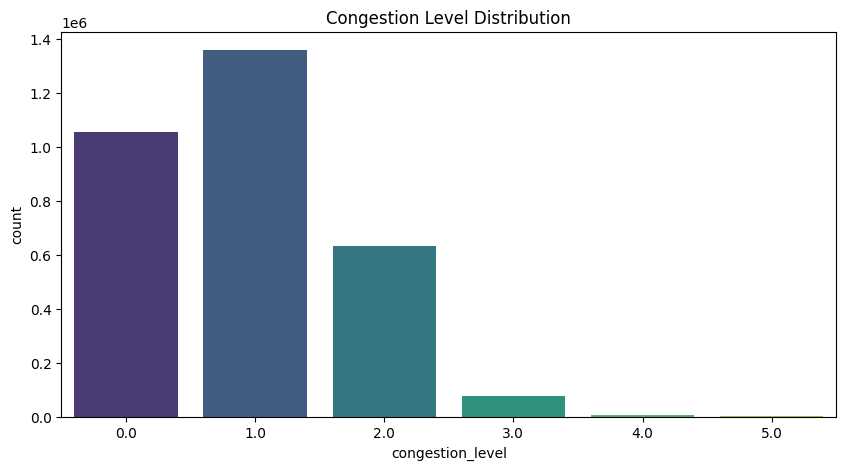

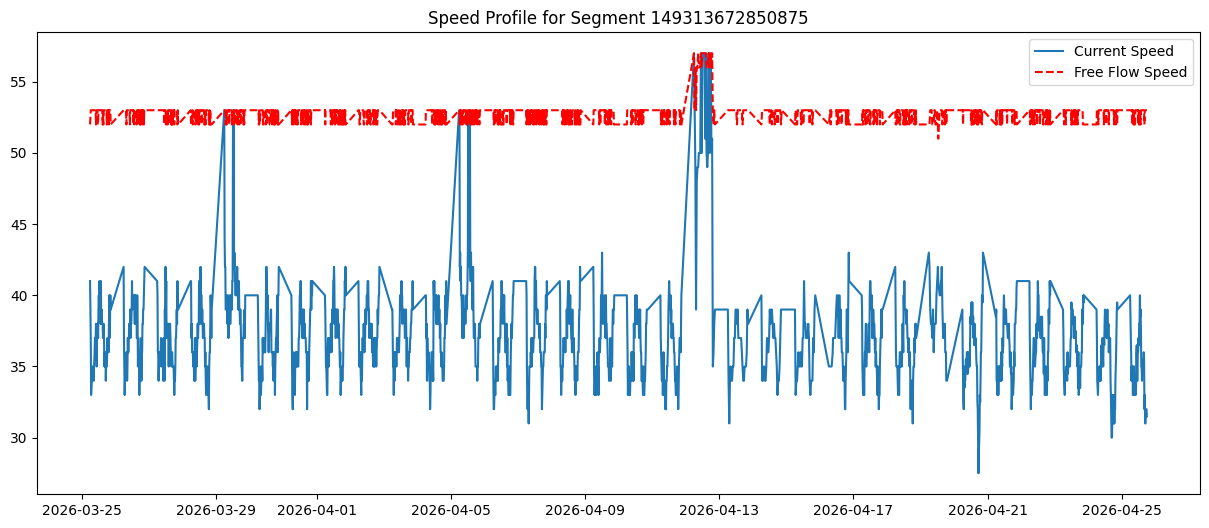

In [7]:
# Visualize congestion level distribution
if 'df' in globals():
    plt.figure(figsize=(10, 5))
    sns.countplot(x='congestion_level', data=df, palette='viridis')
    plt.title('Congestion Level Distribution')
    plt.show()

    # Visualize time series for a sample segment
    if not df.empty:
        sample_seg = df['segment_key'].iloc[0]
        sample_df = df[df['segment_key'] == sample_seg].sort_values('timestamp')
        
        plt.figure(figsize=(15, 6))
        plt.plot(sample_df['timestamp'], sample_df['current_speed_kmh'], label='Current Speed')
        plt.plot(sample_df['timestamp'], sample_df['free_flow_speed_kmh'], 'r--', label='Free Flow Speed')
        plt.title(f'Speed Profile for Segment {sample_seg}')
        plt.legend()
        plt.show()
else:
    print('DataFrame "df" not found. Please run the ETL cells first.')